# CT scan UNet demo

This notebook creates a UNet for a minified dataset of animal CTs.

In [3]:
import pathlib
import urllib.request
import shutil
import collections

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import imageio

INFO:tensorflow:Enabling eager execution
INFO:tensorflow:Enabling v2 tensorshape
INFO:tensorflow:Enabling resource variables
INFO:tensorflow:Enabling tensor equality
INFO:tensorflow:Enabling control flow v2


In [8]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [4]:
zip_url = 'https://zenodo.org/record/4448689/files/minified-animal-patient-brain-orbits.zip?download=1'
zip_filepath = 'data.zip'

data_directory = pathlib.Path('data')

if not data_directory.exists():
    urllib.request.urlretrieve(zip_url, zip_filepath)
    shutil.unpack_archive(zip_filepath, data_directory)

In [5]:
dataset_types = [path.name for path in data_directory.glob('*') if path.is_dir()]
dataset_types

['hold-out', 'training', 'validation']

In [10]:
def _load_image(image_path):
    png_image = imageio.imread(image_path)
    normalised_image = png_image[:,:,None] / 255
    
    return normalised_image


def _load_mask(mask_path):
    png_mask = imageio.imread(mask_path)
    normalised_mask = png_mask / 255
    
    return normalised_mask

In [11]:
def load_dataset_type(dataset_type, shuffle=True, load_masks=True):
    image_suffix = '_image.png'
    mask_suffix = '_mask.png'
    
    dataset_type_directory = data_directory.joinpath(dataset_type)
    
    image_paths = list(dataset_type_directory.glob(f'**/*{image_suffix}'))
    if shuffle:
        np.random.shuffle(image_paths)
        
    uids = [
        (path.parent.name, path.name.replace(image_suffix, ''))
        for path in image_paths
    ]
    
    image_arrays = [
        _load_image(image_path)
        for image_path in image_paths
    ]
    images = np.array(image_arrays)
    
    if not load_masks:
        return uids, images
    
    mask_paths = [
        str(dataset_type_directory.joinpath(uid[0], uid[1])) + mask_suffix
        for uid in uids
    ]
    mask_arrays = [
        _load_mask(mask_path)
        for mask_path in mask_paths
    ]
    masks = np.array(mask_arrays)
    
    return uids, images, masks

In [12]:
_, training_images, training_masks = load_dataset_type('training')
_, validation_images, validation_masks = load_dataset_type('validation', shuffle=False)

In [13]:
def _find_image_with_most_variety(images, masks):
    has_brain = np.sum(masks[:,:,:,1], axis=(1,2))
    has_eyes = np.sum(masks[:,:,:,0], axis=(1,2))

    brain_sort = 1 - np.argsort(has_brain) / len(has_brain)
    eyes_sort = 1 - np.argsort(has_eyes) / len(has_eyes)

    max_combo = np.argmax(brain_sort * eyes_sort * has_brain * has_eyes)

    sample_image = images[max_combo,:,:,:]
    sample_mask = masks[max_combo,:,:,:]
    
    return sample_image, sample_mask


sample_image, sample_mask = _find_image_with_most_variety(
    validation_images, validation_masks
)

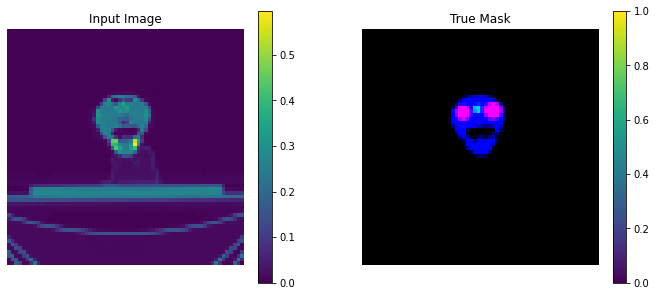

In [14]:
def display(image, mask, prediction=None):
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.title('Input Image')            
    plt.imshow(image[:,:,0])
    plt.colorbar()
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title('True Mask')            
    plt.imshow(mask)
    plt.colorbar()
    plt.axis('off')

    if prediction is None:
        try:
            prediction = model.predict(image[None, ...])[0, ...]
        except NameError:
            return

    plt.subplot(1, 3, 3)
    plt.title('Predicted Mask')            
    plt.imshow(prediction)
    plt.colorbar()
    plt.axis('off')

    
    
class DisplayCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        display(sample_image, sample_mask)
        plt.show()
        print ('\nSample Prediction after epoch {}\n'.format(epoch+1))
    
    
display(sample_image, sample_mask)

In [15]:
def _activation(x):
    x = tf.keras.layers.Activation("relu")(x)

    return x


def _convolution(x, number_of_filters, kernel_size=3):
    x = tf.keras.layers.Conv2D(
        number_of_filters, kernel_size, padding="same", kernel_initializer="he_normal"
    )(x)

    return x


def _conv_transpose(x, number_of_filters, kernel_size=3):
    x = tf.keras.layers.Conv2DTranspose(
        number_of_filters,
        kernel_size,
        strides=2,
        padding="same",
        kernel_initializer="he_normal",
    )(x)

    return x

In [16]:
def encode(
    x,
    number_of_filters,
    number_of_convolutions=2,
):
    for _ in range(number_of_convolutions):
        x = _convolution(x, number_of_filters)
        x = _activation(x)
    skip = x

    x = tf.keras.layers.MaxPool2D()(x)
    x = _activation(x)

    return x, skip

In [17]:
def decode(
    x,
    skip,
    number_of_filters,
    number_of_convolutions=2,
):
    x = _conv_transpose(x, number_of_filters)
    x = _activation(x)

    x = tf.keras.layers.concatenate([skip, x], axis=3)

    for _ in range(number_of_convolutions):
        x = _convolution(x, number_of_filters)
        x = _activation(x)

    return x

In [18]:
mask_dims = training_masks.shape
assert mask_dims[1] == mask_dims[2]
grid_size = int(mask_dims[2])
output_channels = int(mask_dims[-1])

In [19]:
inputs = tf.keras.layers.Input((grid_size, grid_size, 1))
x = inputs
skips = []

for number_of_filters in [32, 64, 128]:
    x, skip = encode(x, number_of_filters)
    skips.append(skip)
    
skips.reverse()

for number_of_filters, skip in zip([256, 128, 64], skips):
    x = decode(x, skip, number_of_filters)
    
x = tf.keras.layers.Conv2D(
    output_channels,
    1,
    activation="sigmoid",
    padding="same",
    kernel_initializer="he_normal",
)(x)

model = tf.keras.Model(inputs=inputs, outputs=x)

In [20]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 64, 64, 1)]  0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 64, 64, 32)   320         input_1[0][0]                    
__________________________________________________________________________________________________
activation (Activation)         (None, 64, 64, 32)   0           conv2d[0][0]                     
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 64, 64, 32)   9248        activation[0][0]                 
______________________________________________________________________________________________

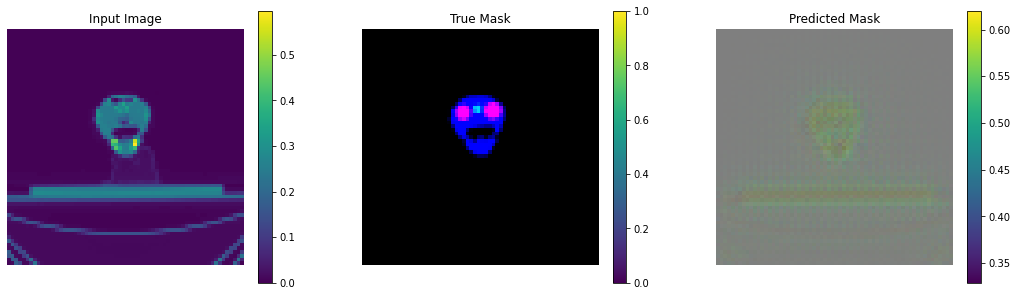

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.Precision()
    ]
)

display(sample_image, sample_mask)

Epoch 1/20
29/29 [==============================] - 3s 51ms/step - loss: 0.2626 - binary_accuracy: 0.9042 - recall: 0.1501 - precision: 0.1419 - val_loss: 0.0158 - val_binary_accuracy: 0.9896 - val_recall: 0.8166 - val_precision: 0.9227


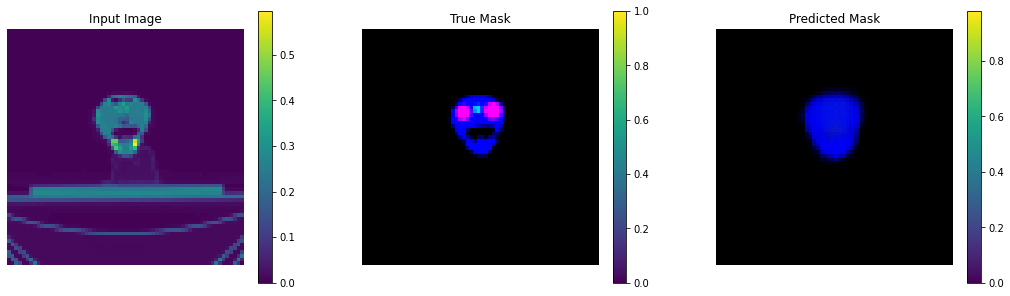


Sample Prediction after epoch 1

Epoch 2/20
29/29 [==============================] - 1s 19ms/step - loss: 0.0175 - binary_accuracy: 0.9879 - recall: 0.7974 - precision: 0.9758 - val_loss: 0.0099 - val_binary_accuracy: 0.9910 - val_recall: 0.7165 - val_precision: 0.9944


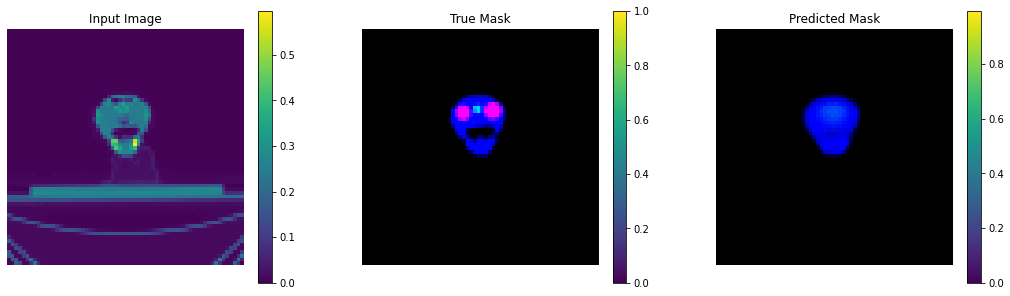


Sample Prediction after epoch 2

Epoch 3/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0124 - binary_accuracy: 0.9886 - recall: 0.7854 - precision: 0.9945 - val_loss: 0.0084 - val_binary_accuracy: 0.9915 - val_recall: 0.8016 - val_precision: 0.9888


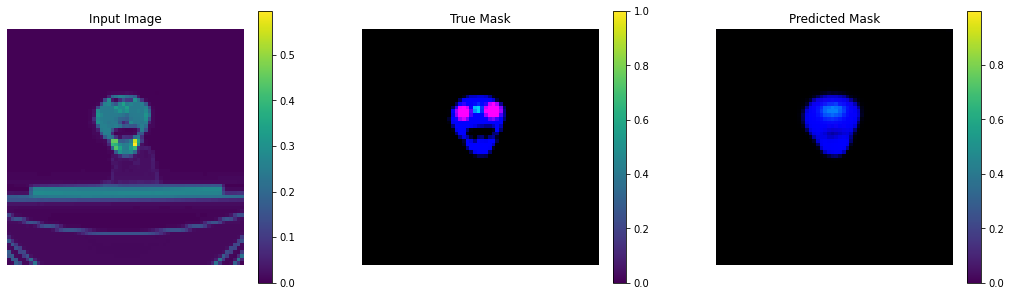


Sample Prediction after epoch 3

Epoch 4/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0103 - binary_accuracy: 0.9893 - recall: 0.8210 - precision: 0.9887 - val_loss: 0.0078 - val_binary_accuracy: 0.9915 - val_recall: 0.8160 - val_precision: 0.9835


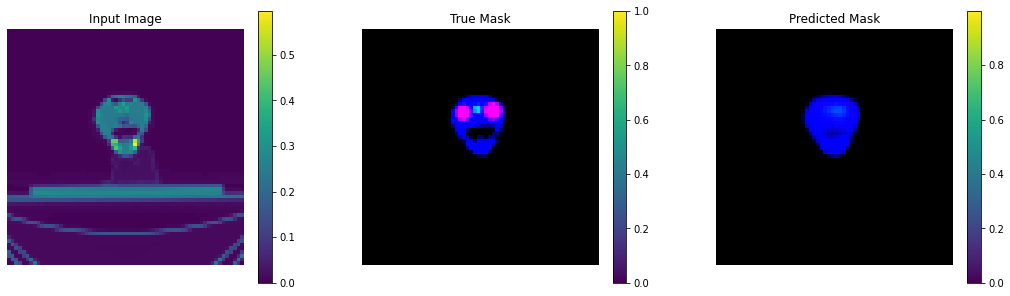


Sample Prediction after epoch 4

Epoch 5/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0104 - binary_accuracy: 0.9891 - recall: 0.8344 - precision: 0.9839 - val_loss: 0.0075 - val_binary_accuracy: 0.9916 - val_recall: 0.7770 - val_precision: 0.9894


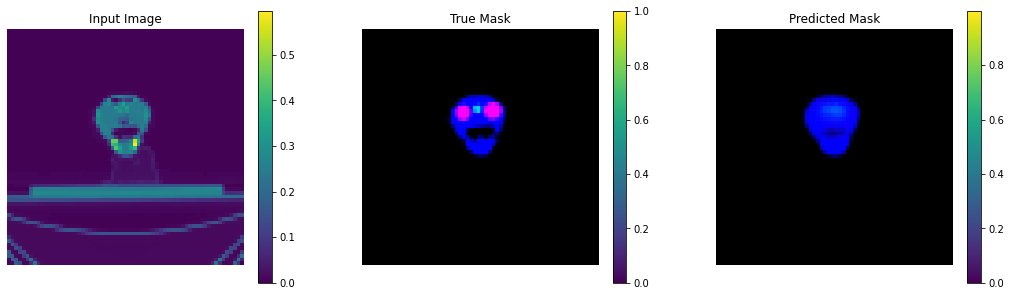


Sample Prediction after epoch 5

Epoch 6/20
29/29 [==============================] - 1s 19ms/step - loss: 0.0088 - binary_accuracy: 0.9897 - recall: 0.8301 - precision: 0.9925 - val_loss: 0.0069 - val_binary_accuracy: 0.9916 - val_recall: 0.7771 - val_precision: 0.9938


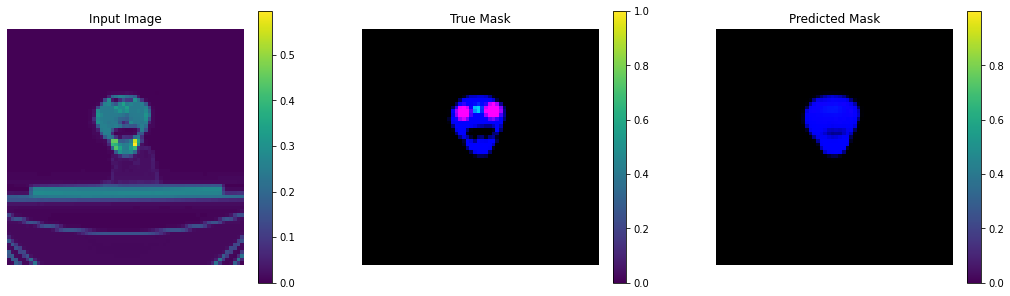


Sample Prediction after epoch 6

Epoch 7/20
29/29 [==============================] - 1s 19ms/step - loss: 0.0080 - binary_accuracy: 0.9897 - recall: 0.8353 - precision: 0.9940 - val_loss: 0.0071 - val_binary_accuracy: 0.9916 - val_recall: 0.7602 - val_precision: 0.9967


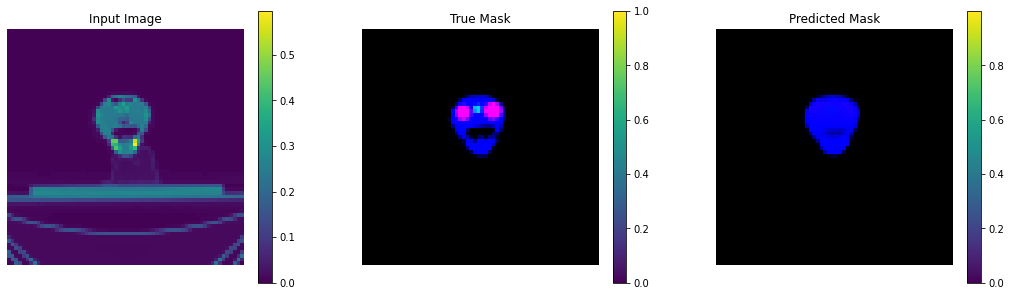


Sample Prediction after epoch 7

Epoch 8/20
29/29 [==============================] - 1s 19ms/step - loss: 0.0074 - binary_accuracy: 0.9898 - recall: 0.8359 - precision: 0.9968 - val_loss: 0.0070 - val_binary_accuracy: 0.9916 - val_recall: 0.7931 - val_precision: 0.9923


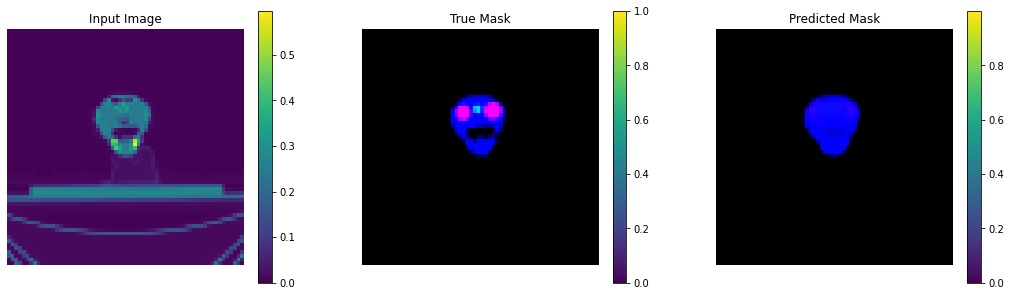


Sample Prediction after epoch 8

Epoch 9/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0070 - binary_accuracy: 0.9899 - recall: 0.8347 - precision: 0.9978 - val_loss: 0.0073 - val_binary_accuracy: 0.9916 - val_recall: 0.7667 - val_precision: 0.9965


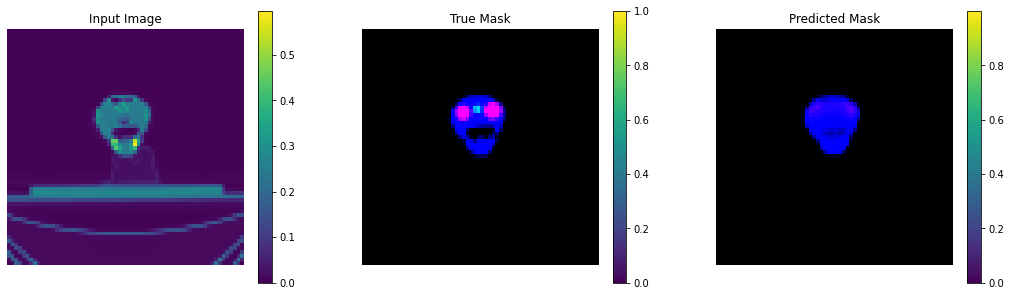


Sample Prediction after epoch 9

Epoch 10/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0070 - binary_accuracy: 0.9898 - recall: 0.8385 - precision: 0.9976 - val_loss: 0.0076 - val_binary_accuracy: 0.9914 - val_recall: 0.7387 - val_precision: 0.9983


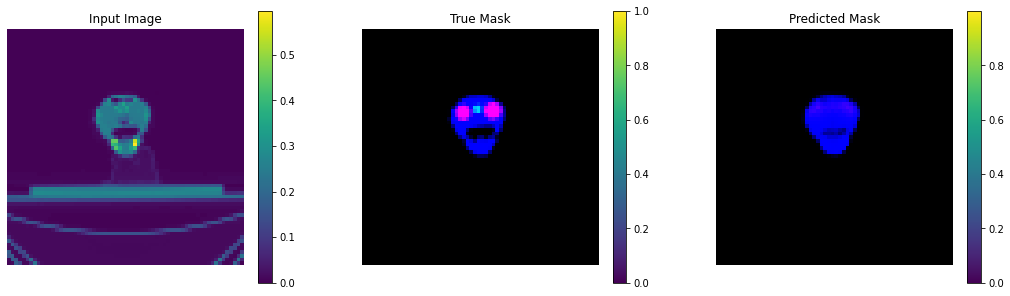


Sample Prediction after epoch 10

Epoch 11/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0069 - binary_accuracy: 0.9898 - recall: 0.8329 - precision: 0.9978 - val_loss: 0.0067 - val_binary_accuracy: 0.9916 - val_recall: 0.7530 - val_precision: 0.9971


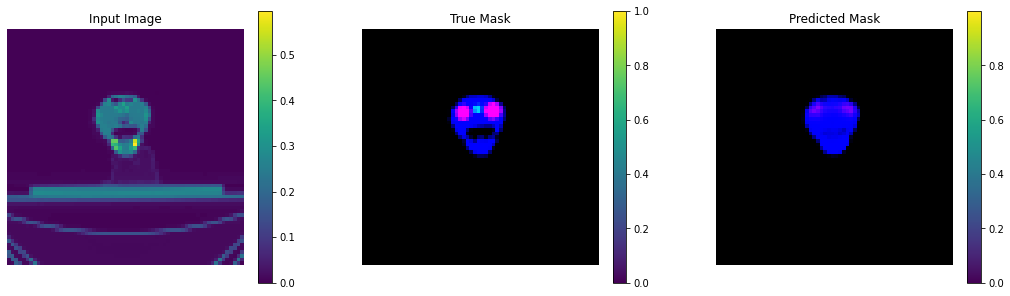


Sample Prediction after epoch 11

Epoch 12/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0062 - binary_accuracy: 0.9898 - recall: 0.8359 - precision: 0.9988 - val_loss: 0.0067 - val_binary_accuracy: 0.9916 - val_recall: 0.7558 - val_precision: 0.9969


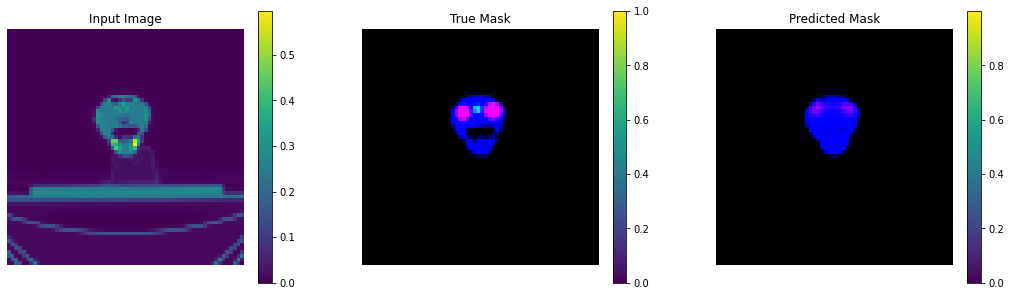


Sample Prediction after epoch 12

Epoch 13/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0061 - binary_accuracy: 0.9901 - recall: 0.8374 - precision: 0.9987 - val_loss: 0.0064 - val_binary_accuracy: 0.9916 - val_recall: 0.7947 - val_precision: 0.9916


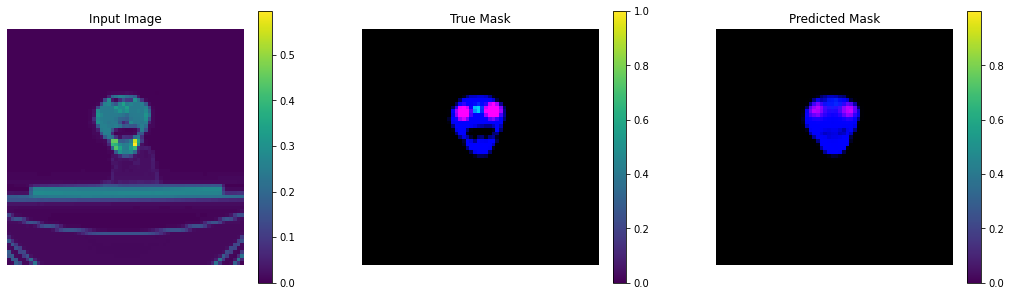


Sample Prediction after epoch 13

Epoch 14/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0059 - binary_accuracy: 0.9899 - recall: 0.8440 - precision: 0.9986 - val_loss: 0.0060 - val_binary_accuracy: 0.9917 - val_recall: 0.7834 - val_precision: 0.9922


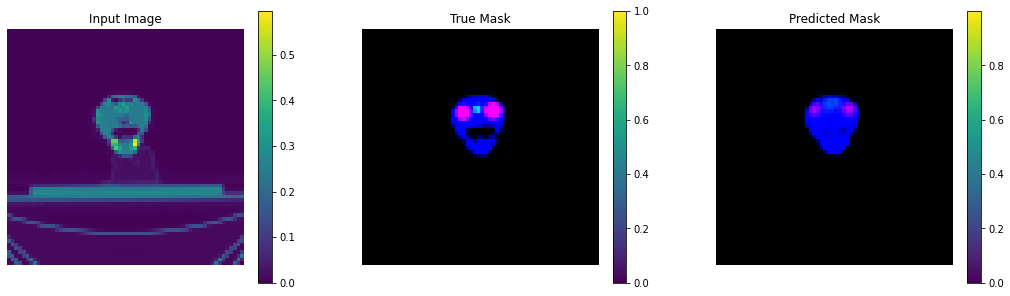


Sample Prediction after epoch 14

Epoch 15/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0058 - binary_accuracy: 0.9900 - recall: 0.8431 - precision: 0.9988 - val_loss: 0.0061 - val_binary_accuracy: 0.9917 - val_recall: 0.7795 - val_precision: 0.9940


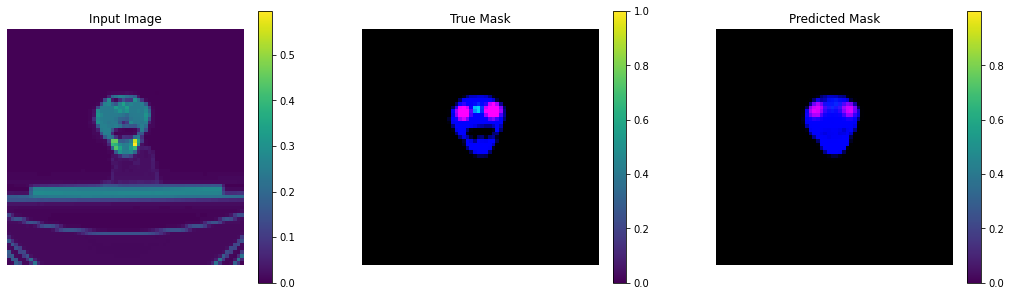


Sample Prediction after epoch 15

Epoch 16/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0054 - binary_accuracy: 0.9901 - recall: 0.8478 - precision: 0.9993 - val_loss: 0.0059 - val_binary_accuracy: 0.9917 - val_recall: 0.7998 - val_precision: 0.9910


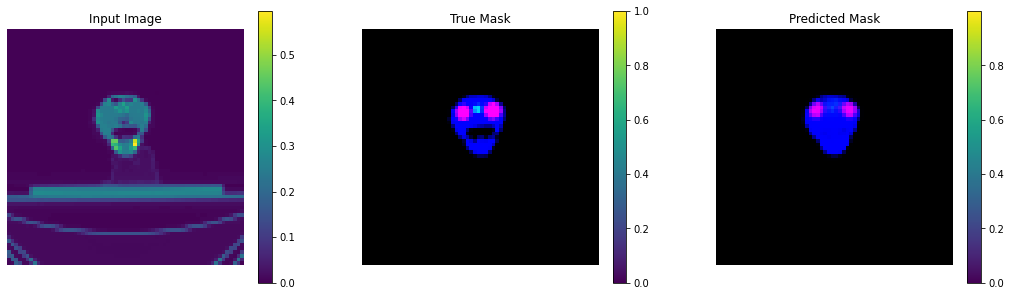


Sample Prediction after epoch 16

Epoch 17/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0055 - binary_accuracy: 0.9901 - recall: 0.8482 - precision: 0.9993 - val_loss: 0.0063 - val_binary_accuracy: 0.9917 - val_recall: 0.7791 - val_precision: 0.9952


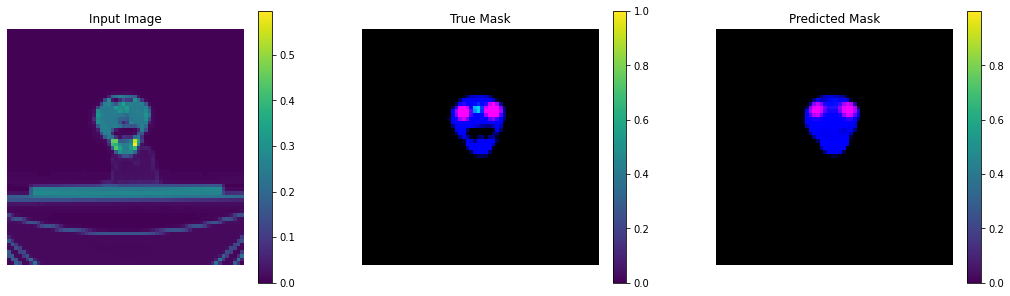


Sample Prediction after epoch 17

Epoch 18/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0055 - binary_accuracy: 0.9901 - recall: 0.8461 - precision: 0.9993 - val_loss: 0.0064 - val_binary_accuracy: 0.9916 - val_recall: 0.7742 - val_precision: 0.9901


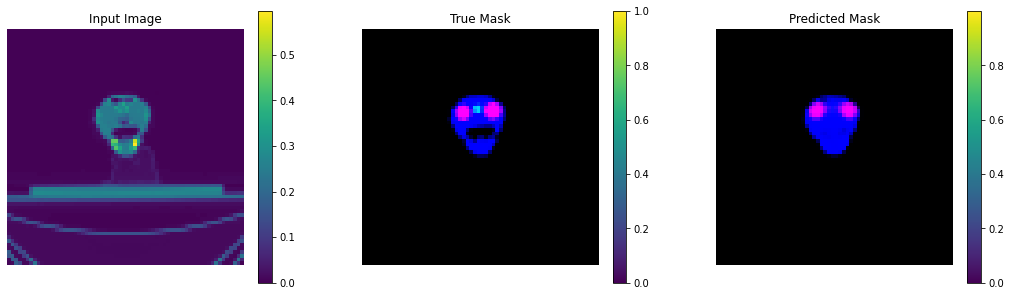


Sample Prediction after epoch 18

Epoch 19/20
29/29 [==============================] - 1s 20ms/step - loss: 0.0054 - binary_accuracy: 0.9900 - recall: 0.8432 - precision: 0.9994 - val_loss: 0.0066 - val_binary_accuracy: 0.9917 - val_recall: 0.7684 - val_precision: 0.9964


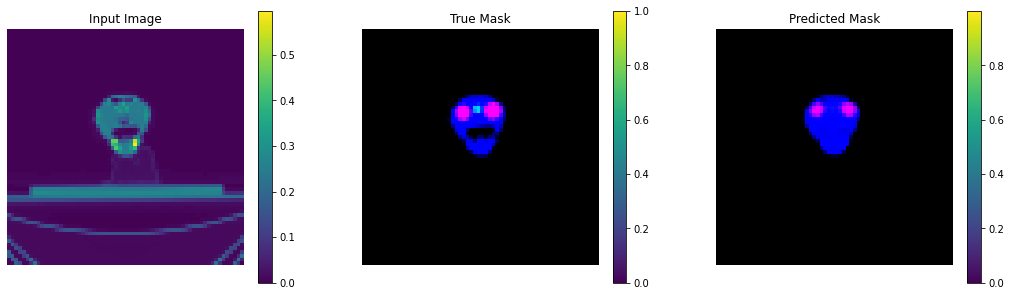


Sample Prediction after epoch 19

Epoch 20/20
29/29 [==============================] - 1s 19ms/step - loss: 0.0053 - binary_accuracy: 0.9901 - recall: 0.8479 - precision: 0.9995 - val_loss: 0.0059 - val_binary_accuracy: 0.9917 - val_recall: 0.8017 - val_precision: 0.9894


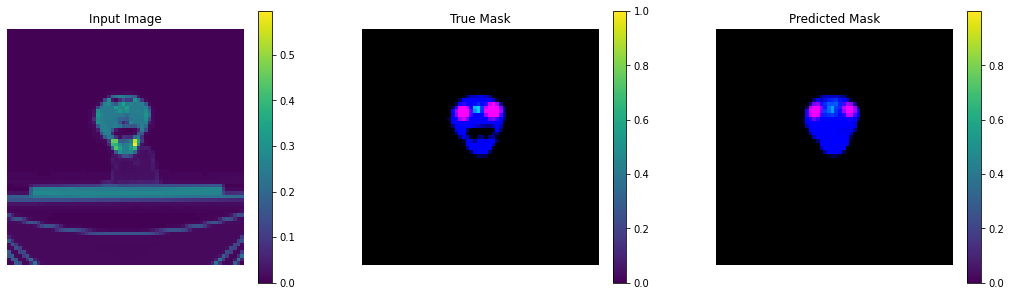


Sample Prediction after epoch 20



In [22]:
history = model.fit(
    training_images, 
    training_masks,
    epochs=20,
    validation_data=(validation_images, validation_masks),
    callbacks=[DisplayCallback()]
)

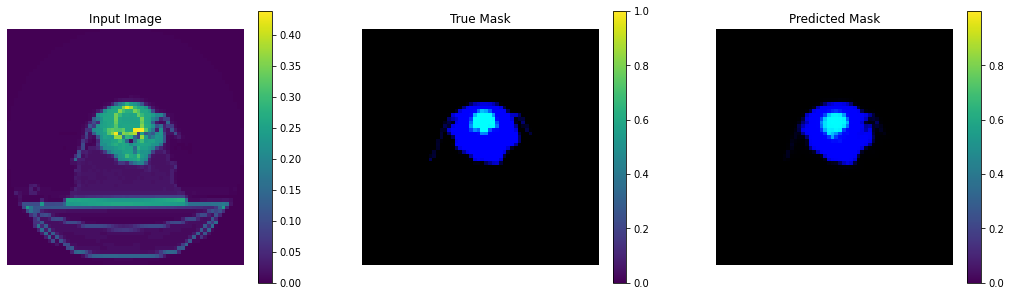

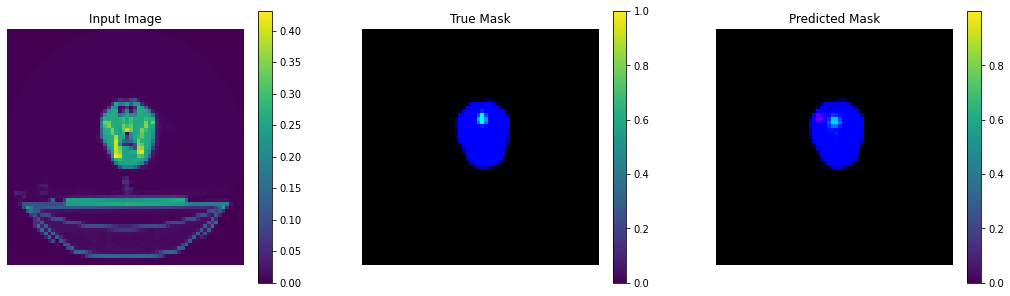

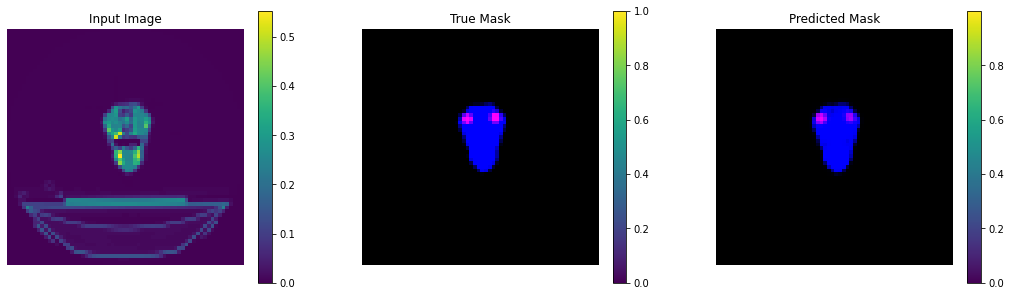

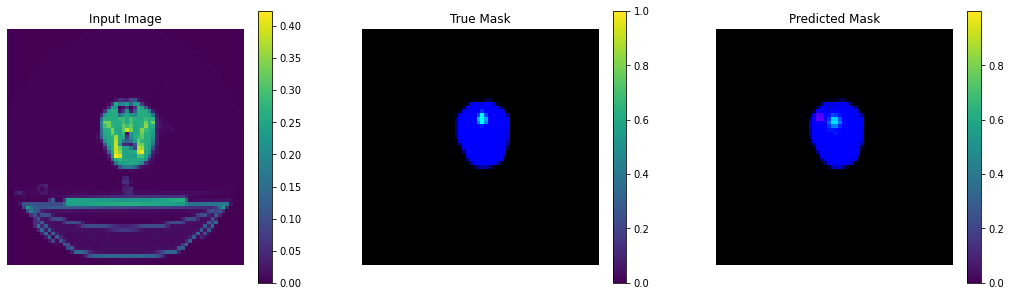

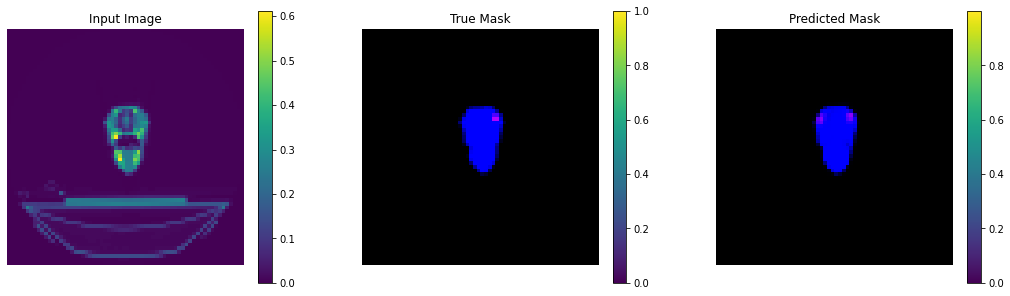

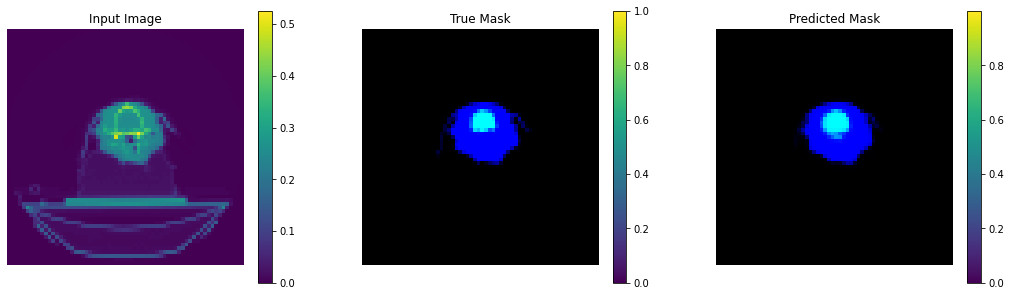

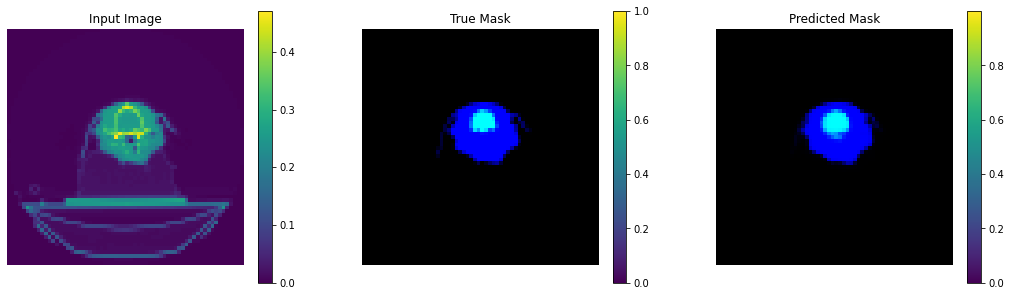

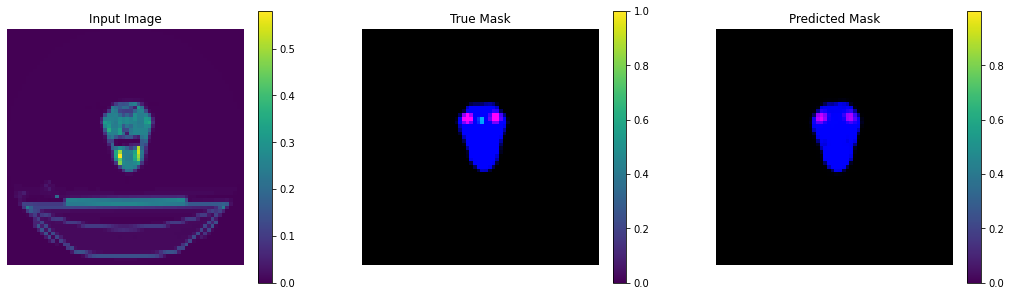

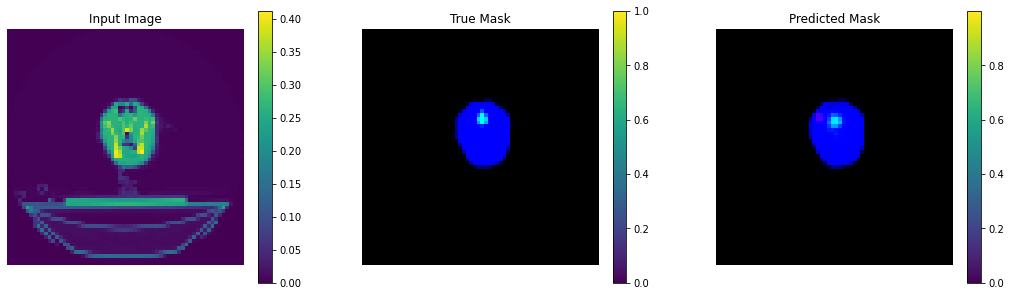

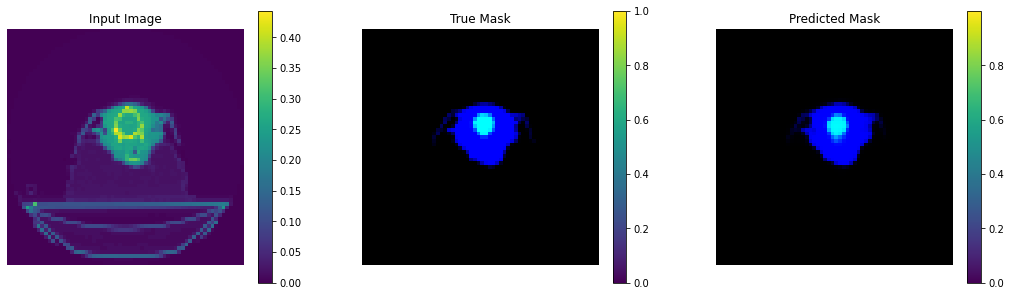

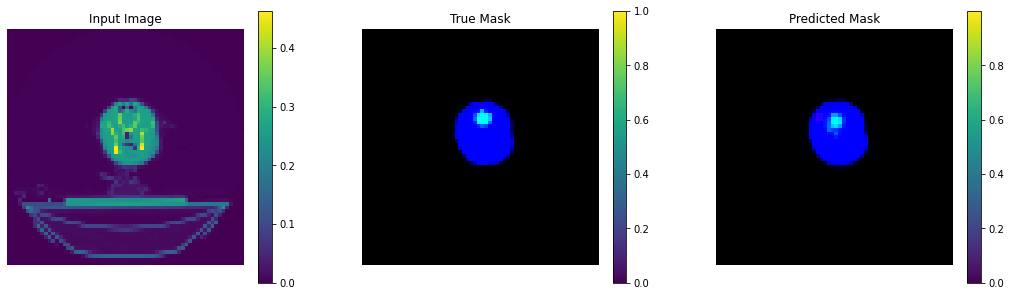

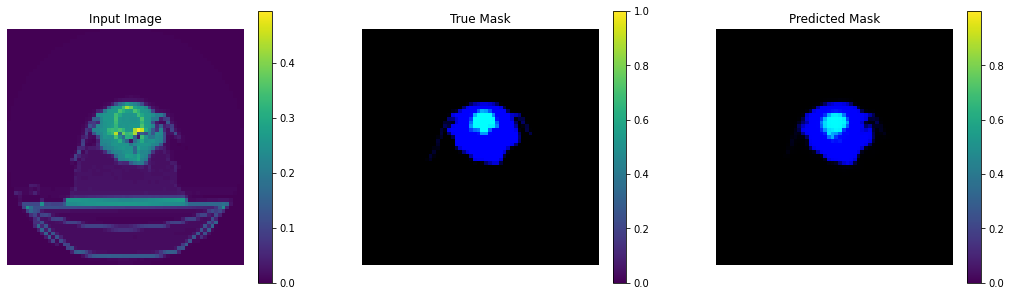

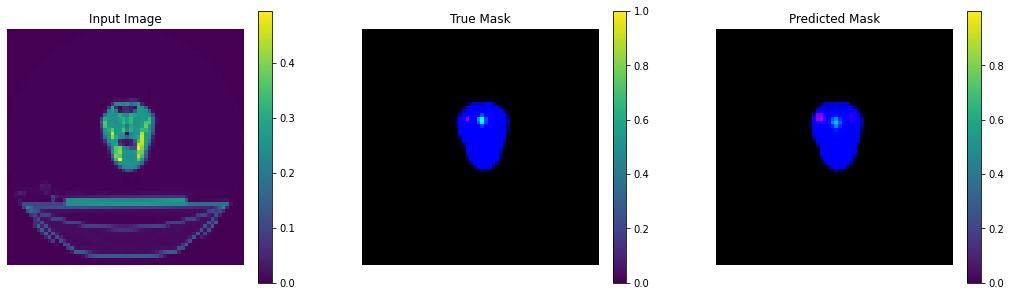

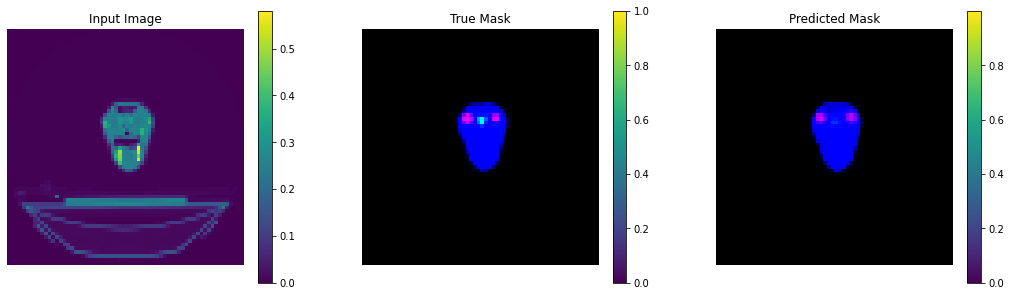

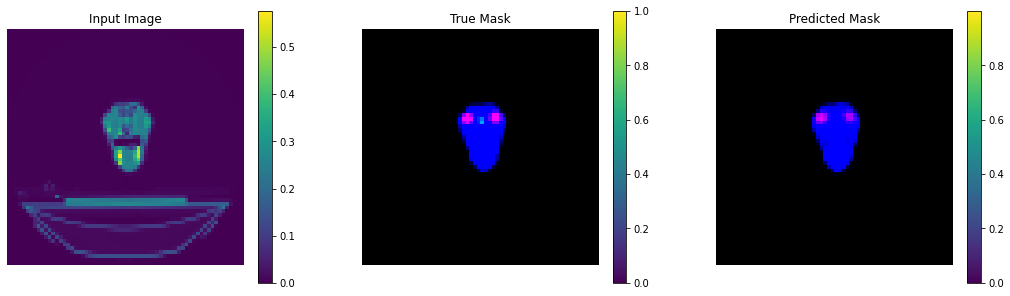

In [23]:
predictions = model.predict(validation_images)

image_combos = list(zip(validation_images, validation_masks, predictions))
num_to_display = 15

for image, mask, prediction in image_combos[0:num_to_display]:
    display(image, mask, prediction)
    plt.show()

In [24]:
hold_out_uids, hold_out_images = load_dataset_type('hold-out', load_masks=False, shuffle=False)
hold_out_predictions = model.predict(hold_out_images)

In [25]:
def _scale_images(image):
    scaled = image * 255
    scaled = scaled.astype(np.uint8)
    
    return scaled

In [26]:
output_directory = pathlib.Path('output')

for uids, image, prediction in zip(hold_out_uids, hold_out_images, hold_out_predictions):
    studyset_uid_directory = output_directory.joinpath(uids[0])
    studyset_uid_directory.mkdir(exist_ok=True, parents=True)
    
    scaled_image = _scale_images(image)
    scaled_prediction = _scale_images(prediction)
    
    common_filepath_start = str(studyset_uid_directory.joinpath(uids[1]))
    
    image_filepath = common_filepath_start + '_image.png'
    prediction_filepath = common_filepath_start + '_prediction.png'
    
    imageio.imsave(image_filepath, scaled_image)
    imageio.imsave(prediction_filepath, scaled_prediction)

    
shutil.make_archive(output_directory.name, 'zip', output_directory)

'/home/simon/git/pymedphys/prototyping/jax/output.zip'